In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = '/content/drive/MyDrive/[SKN]2nd_prj/internet_service_churn.csv'
df_re = pd.read_csv(path, encoding='utf-8')
df_re.head(1)

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0


# ☀ preprocessing - ml

In [3]:
# id 컬럼 삭제
df_re = df_re.drop(columns=['id'])

In [4]:
# 음수값 제거
df_re = df_re[df_re['subscription_age'] >= 0]

In [5]:
# `reamining_contract` grouping
import numpy as np

conditions = [
    df_re['reamining_contract'].isnull(),
    df_re['reamining_contract'] == 0,
    df_re['reamining_contract'] > 0
]

choices = ['no_contract', 'expired', 'active']

df_re['contract_type'] = np.select(conditions, choices, default='unknown')

In [6]:
# 원핫인코딩
df_re = pd.get_dummies(df_re, columns=['contract_type'], dtype=int)

In [7]:

# `reamining_contract` drop
df_re = df_re.drop(columns=['reamining_contract'])

In [8]:
df_re.head(2)

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,service_failure_count,download_avg,upload_avg,download_over_limit,churn,contract_type_active,contract_type_expired,contract_type_no_contract
0,1,0,11.95,25,0,8.4,2.3,0,0,1,0,0
1,0,0,8.22,0,0,0.0,0.0,0,1,0,0,1


In [9]:
# `download_avg` NaN 드랍
df_re = df_re.dropna(subset=['download_avg'])

In [10]:
# `download_avg`의 널값을 제거하면, `upload_avg`의 널값도 제거된 것을 확인
df_re['upload_avg'].isna().sum()

np.int64(0)

In [11]:
# 구독 상태 통합 컬럼 생성
df_re['subscription_label'] = df_re.apply(
    lambda row: (
        'both' if row['is_tv_subscriber'] == 1 and row['is_movie_package_subscriber'] == 1 else
        'tv' if row['is_tv_subscriber'] == 1 else
        'movie' if row['is_movie_package_subscriber'] == 1 else
        'none'
    ),
    axis=1
)

df_re.drop(['is_tv_subscriber', 'is_movie_package_subscriber'], axis=1, inplace=True)

# 원핫인코딩
df_re = pd.get_dummies(df_re, columns=['subscription_label'], prefix='sub')

dummy_cols = [col for col in df_re.columns if col.startswith('sub_')]
df_re[dummy_cols] = df_re[dummy_cols].astype(int)

In [12]:
df_re.head(1)

,subscription_age,bill_avg,service_failure_count,download_avg,upload_avg,download_over_limit,churn,contract_type_active,contract_type_expired,contract_type_no_contract,sub_both,sub_movie,sub_none,sub_tv
0,11.95,25,0,8.4,2.3,0,0,1,0,0,0,0,0,1


In [13]:
import numpy as np

for col in ['bill_avg', 'download_avg', 'upload_avg']:
    df_re[f'{col}_log'] = np.log1p(df_re[col])  # log(1+x)으로 0 방지

In [14]:
# 기존 컬럼 삭제
df_re.drop(['bill_avg', 'download_avg', 'upload_avg'], axis=1, inplace=True)

In [15]:
# df_re.to_csv("re_log_model_preprocessed.csv", index=False, encoding='utf-8-sig')

# from google.colab import files
# files.download("re_log_model_preprocessed.csv")

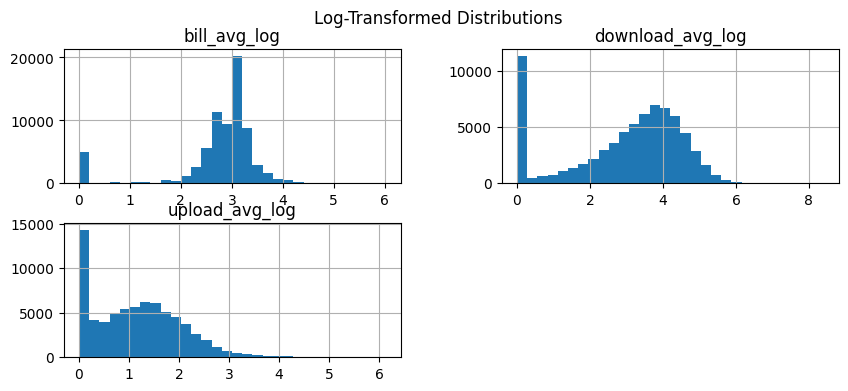

In [ ]:
import matplotlib.pyplot as plt

df_re[[f'{col}_log' for col in ['bill_avg', 'download_avg', 'upload_avg']]].hist(bins=30, figsize=(10,4))
plt.suptitle('Log-Transformed Distributions')
plt.show()